# Topic Modelling: Which Topics Are Associated with Higher MAGPIE Scores?

This notebook looks at a question that goes beyond the main left-versus-right analysis: **do some topics in German news tend to receive higher or lower MAGPIE bias scores than others?**

For this analysis, a separate and larger sample of **5,000 articles** is used. The larger sample gives BERTopic more articles to work with when identifying recurring topics.

This analysis is separate from the main German hypothesis test in `01_german_analysis.ipynb`. It does not change or repeat the main left/right comparison. Instead, it is used to explore whether the MAGPIE scores vary with the type of content being discussed.

## Setup

This notebook uses the same multilingual MAGPIE model as the main German analysis to score the articles. BERTopic, sentence-transformers, UMAP, and HDBSCAN are added here to identify recurring topics from the article text.

In [ ]:
# Install the packages needed for MAGPIE scoring and topic modelling.
!pip install transformers pandas scikit-learn scipy tqdm statsmodels -q
!pip install bertopic sentence-transformers umap-learn hdbscan -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.1 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline

# Use the same multilingual MAGPIE model as in the German and Spanish analyses.
bias_classifier = pipeline(
    "text-classification",
    model="mediabiasgroup/magpie-babe-ft-xlm",
    device=0
)

config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/451 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

## Load the data and draw a larger sample

The same German OSCAR corpus used in the main German analysis is used here. For topic modelling, a separate and larger sample of **5,000 articles** is drawn, with 2,500 articles labelled left and 2,500 labelled right.

A different random seed (`123` instead of `42`) is used so that this sample is separate from the main German analysis sample.

In [ ]:
# Read the German OSCAR corpus and keep line breaks within each article.
import pandas as pd

columns = ["topic10", "topic15", "stance", "oscarID", "url", "text"]

rows = []
current = None

with open(
    "poliOscar.complete.de",
    "r",
    encoding="utf-8",
    errors="replace"
) as f:

    for raw_line in f:
        line = raw_line.rstrip("\r\n")
        parts = line.split("\t", 5)

        if len(parts) >= 5 and parts[2] in ["left", "right"]:
            if current is not None:
                rows.append(current)

            while len(parts) < 6:
                parts.append("")

            current = parts[:6]

        elif current is not None:
            current[5] += "\n" + line

if current is not None:
    rows.append(current)

df = pd.DataFrame(rows, columns=columns)

print("Full corpus records:", len(df))

print("\nStance distribution:")
print(df["stance"].value_counts())

print(
    "\nRecords with missing article text:",
    df["text"].str.strip().eq("").sum()
)

Full corpus records: 143200

Stance distribution:
stance
left     88102
right    55098
Name: count, dtype: int64

Records with missing article text: 3081


In [ ]:
print(df["text"].iloc[0][:500])

Berlin (dpa/bb) - Ein halbes Jahr vor der Wahl zum Abgeordnetenhaus haben die Grünen ihren Plan für ein klimaneutrales Berlin beschlossen. Die Delegierten eines Online-Parteitages stimmten am Freitagabend für eine Null-Emissions-Zone (Zero Emission Zone): Ab 2030 sollen demzufolge innerhalb des S-Bahn-Rings keine Autos mit fossilen Antrieben mehr fahren, bis 2035 soll das Modell auf die ganze Stadt ausgeweitet werden. Zudem sollen nach dem Willen der Öko-Partei bis 2025 alle landeseigenen Gebäud


In [ ]:
# Draw a separate 5,000-article sample using seed 123.

df_usable = df[df["text"].astype(str).str.strip().ne("")].copy()

# Clean the stance labels before sampling.
df_usable["stance"] = (
    df_usable["stance"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Available stance labels:")
print(df_usable["stance"].value_counts())

# Keep the two stance groups used for the analysis.
left_articles = df_usable[df_usable["stance"] == "left"]
right_articles = df_usable[df_usable["stance"] == "right"]

print("\nUsable left articles:", len(left_articles))
print("Usable right articles:", len(right_articles))

# Check that enough articles are available for the sample.
if len(left_articles) < 2500 or len(right_articles) < 2500:
    raise ValueError(
        f"Not enough articles for the 5,000-article sample. "
        f"Left={len(left_articles)}, Right={len(right_articles)}"
    )

left_sample = left_articles.sample(
    n=2500,
    random_state=123
)

right_sample = right_articles.sample(
    n=2500,
    random_state=123
)

df_topics = (
    pd.concat([left_sample, right_sample])
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)

print("\nTopic-modelling sample:", df_topics.shape)

print("\nStance distribution:")
print(df_topics["stance"].value_counts())

print("\nUnique oscarID:", df_topics["oscarID"].nunique())
print("Duplicate oscarID:", df_topics["oscarID"].duplicated().sum())

print("\nUnique URLs:", df_topics["url"].nunique())
print("Duplicate URLs:", df_topics["url"].duplicated().sum())

print("\nExisting corpus topic labels:")
print(df_topics["topic10"].value_counts())

Available stance labels:
stance
left     88102
right    52017
Name: count, dtype: int64

Usable left articles: 88102
Usable right articles: 52017

Topic-modelling sample: (5000, 6)

Stance distribution:
stance
right    2500
left     2500
Name: count, dtype: int64

Unique oscarID: 5000
Duplicate oscarID: 0

Unique URLs: 4986
Duplicate URLs: 14

Existing corpus topic labels:
topic10
10:0    707
10:8    579
10:2    564
10:4    532
10:3    524
10:1    496
10:9    470
10:5    468
10:7    392
10:6    268
Name: count, dtype: int64


In [ ]:
# Remove the <NS> paragraph marker before topic modelling.
df_topics["text_for_topics"] = (
    df_topics["text"]
    .astype(str)
    .str.replace("<NS>", " ", regex=False)
    .str.strip()
)

print(
    "Remaining <NS> markers:",
    df_topics["text_for_topics"].str.contains("<NS>", regex=False).sum()
)

Remaining <NS> markers: 0


## Score every article with MAGPIE

The same scoring approach used in the German and Spanish analyses is applied here. MAGPIE first produces sentence-level bias probabilities, which are then aggregated into article-level scores using average, maximum, and median pooling.

In [ ]:
import re

def split_into_sentences(text):
    paragraphs = text.split("<NS>")
    sentences_all = []

    for paragraph in paragraphs:
        paragraph = paragraph.strip()

        if not paragraph:
            continue

        sentences = re.split(r'(?<=[.!?]) +', paragraph)
        sentences_all.extend(
            [s.strip() for s in sentences if s.strip()]
        )

    return sentences_all

In [ ]:
import statistics

def score_article(text, classifier, batch_size=32):
    """Score all sentences in an article and return average, max, and median
    MAGPIE scores from the same set of sentence-level predictions."""

    if pd.isna(text) or len(text.strip()) == 0:
        return None, None, None

    sentences = split_into_sentences(text)

    if len(sentences) == 0:
        return None, None, None

    results = classifier(
        sentences,
        truncation=True,
        batch_size=batch_size
    )

    labels = [r["label"] for r in results]

    biased_probs = [
        r["score"] if r["label"] == "biased" else 1 - r["score"]
        for r in results
    ]

    avg_score = sum(biased_probs) / len(biased_probs)
    max_score = max(biased_probs)
    median_score = statistics.median(biased_probs)

    return avg_score, max_score, median_score

In [ ]:
from tqdm import tqdm

avg_scores, max_scores, median_scores = [], [], []

for idx, row in tqdm(df_topics.iterrows(), total=len(df_topics)):
    avg_s, max_s, median_s = score_article(row["text"], bias_classifier)

    avg_scores.append(avg_s)
    max_scores.append(max_s)
    median_scores.append(median_s)

df_topics["bias_score"] = avg_scores
df_topics["max_bias_score"] = max_scores
df_topics["median_bias_score"] = median_scores

print("Scoring complete.")
print(f"Articles without a score: {df_topics['bias_score'].isna().sum()}")

df_topics = df_topics.dropna(subset=["bias_score"]).reset_index(drop=True)

print("Final usable articles:", df_topics.shape[0])

100%|██████████| 5000/5000 [03:55<00:00, 21.22it/s]

Scoring complete.
Articles without a score: 0
Final usable articles: 5000


## Discover topics with BERTopic

This is the main topic-modelling step. BERTopic combines four stages to identify groups of articles with similar content:

1. **Embed:** Each article is converted into a meaning-based vector using a multilingual sentence-embedding model. A multilingual model is used because the articles are in German.
2. **Reduce:** UMAP reduces the dimensionality of these vectors so that they can be clustered more effectively.
3. **Cluster:** HDBSCAN groups similar articles into topics and determines the number of clusters from the data. Articles that do not fit well into a cluster can be marked as outliers (`-1`) rather than being forced into a topic.
4. **Represent:** BERTopic identifies representative words for each cluster, which helps describe and interpret the resulting topics.

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from umap import UMAP

# Use a multilingual embedding model because the articles are in German.
embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

# Remove common German stopwords from the topic representations.
german_stopwords = [
    "der", "die", "das", "den", "dem", "des",
    "ein", "eine", "einer", "einem", "einen", "eines",
    "und", "oder", "aber", "auch", "noch", "nur",
    "ist", "sind", "war", "waren", "wird", "werden",
    "von", "zu", "mit", "für", "auf", "in", "im", "an",
    "aus", "bei", "als", "nicht", "sich", "es",
    "er", "sie", "ihm", "ihn", "ihr", "ihre",
    "wie", "dass", "dem", "denn"
]

vectorizer_model = CountVectorizer(
    stop_words=german_stopwords
)

# Reduce the embedding dimensions before clustering.
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=123
)

# Use leaf clustering to obtain a more granular topic structure.
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    cluster_selection_method="leaf",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(
    df_topics["text_for_topics"].tolist()
)

df_topics["topic"] = topics

n_topics = len(set(topics)) - (1 if -1 in topics else 0)
n_outliers = (df_topics["topic"] == -1).sum()

print(f"Number of topics found (excluding outliers): {n_topics}")
print(f"Articles marked as outliers (topic = -1): {n_outliers}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-09-24 07:48:07,607 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-09-24 07:48:26,602 - BERTopic - Embedding - Completed ✓
2026-09-24 07:48:26,611 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-24 07:48:37,516 - BERTopic - Dimensionality - Completed ✓
2026-09-24 07:48:37,517 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-24 07:48:37,758 - BERTopic - Cluster - Completed ✓
2026-09-24 07:48:37,762 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-24 07:48:40,598 - BERTopic - Representation - Completed ✓


Number of topics found (excluding outliers): 29
Articles marked as outliers (topic = -1): 2010


In [ ]:
# Inspect the discovered topics and their sizes.
topic_info = topic_model.get_topic_info()

print(topic_info[["Topic", "Count", "Name"]].to_string(index=False))


 Topic  Count                                         Name
    -1   2010                            -1_hat_so_nach_am
     0    486                         0_spd_partei_cdu_afd
     1    449                 1_nach_gegen_trainer_fußball
     2    202                      2_polizei_am_nach_wurde
     3    176 3_flüchtlinge_migranten_deutschland_menschen
     4    171                    4_corona_am_inzidenz_nach
     5    160                5_google_facebook_daten_apple
     6    123                 6_tiere_mörser_zum_vergleich
     7    110                      7_ich_kinder_haben_mehr
     8    100                        8_vw_prozent_co2_euro
     9     96                     9_wohnungen_stadt_man_so
    10     68                10_trump_us_demokraten_donald
    11     67              11_kunst_ausstellung_museum_hat
    12     66                     12_75_ich_hanks_ausgaben
    13     65                          13_bahn_um_züge_bis
    14     58                          14_taz_ich_über_m

In [ ]:
# Show the main keywords for each discovered topic.
for topic_num in sorted(df_topics["topic"].unique()):
    if topic_num == -1:
        continue

    words = topic_model.get_topic(topic_num)
    top_words = ", ".join([word[0] for word in words[:10]])
    count = (df_topics["topic"] == topic_num).sum()

    print(f"Topic {topic_num} ({count} articles): {top_words}")

Topic 0 (486 articles): spd, partei, cdu, afd, hat, grünen, am, vor, nach, wir
Topic 1 (449 articles): nach, gegen, trainer, fußball, ich, fc, hat, spiel, am, bayern
Topic 2 (202 articles): polizei, am, nach, wurde, habe, vor, haben, hatte, gegen, sei
Topic 3 (176 articles): flüchtlinge, migranten, deutschland, menschen, nach, eu, wir, vor, am, mehr
Topic 4 (171 articles): corona, am, inzidenz, nach, mehr, bayern, menschen, uhr, oktober, wert
Topic 5 (160 articles): google, facebook, daten, apple, internet, nutzer, app, hat, so, um
Topic 6 (123 articles): tiere, mörser, zum, vergleich, so, hat, vor, mehr, sagt, wenn
Topic 7 (110 articles): ich, kinder, haben, mehr, man, wenn, eltern, wir, hat, so
Topic 8 (100 articles): vw, prozent, co2, euro, um, bis, nach, über, hat, autos
Topic 9 (96 articles): wohnungen, stadt, man, so, mieter, um, euro, hat, am, vor
Topic 10 (68 articles): trump, us, demokraten, donald, präsident, republikaner, trumps, biden, obama, usa
Topic 11 (67 articles): kun

## Does bias score differ by topic?

Now that each article has been assigned a topic, this analysis examines whether MAGPIE scores differ across topics.

Because there are more than two topic groups, the **Kruskal-Wallis H-test** is used instead of the Mann-Whitney U test. It tests whether the score distributions differ across at least one of the topic groups.

In [ ]:
# Exclude outliers (-1) because they were not assigned to a specific topic.
df_clustered = df_topics[df_topics["topic"] != -1].copy()

df_clustered.groupby("topic")["bias_score"].agg(
    ["mean", "median", "count"]
).sort_values("mean", ascending=False)

,mean,median,count
topic,,,
26,0.422108,0.403897,36
22,0.410241,0.389140,41
10,0.406462,0.408939,68
16,0.389115,0.395545,52
21,0.380565,0.376067,41
0,0.333945,0.325826,486
28,0.330655,0.331805,32
24,0.324665,0.331104,39
14,0.316549,0.304508,58


In [ ]:
from scipy.stats import kruskal

groups = [
    group["bias_score"].dropna().values
    for _, group in df_clustered.groupby("topic")
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Number of topics compared: {len(groups)}")

if p_value < 0.05:
    print(">> At least one topic group differs significantly in MAGPIE scores.")
else:
    print(">> No significant difference was found across the topic groups.")

Kruskal-Wallis H-statistic: 339.6720
P-value: 0.0000
Number of topics compared: 29
>> At least one topic group differs significantly in MAGPIE scores.


## If significant: which specific topics differ?

The Kruskal-Wallis test shows whether there is evidence of a difference across the topic groups, but it does not identify which groups differ.

If the Kruskal-Wallis test is significant, pairwise Mann-Whitney U tests are used to compare the topic groups. A Bonferroni correction is then applied across all pairwise comparisons to account for multiple testing.

In [ ]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Pairwise Mann-Whitney U tests between topic groups
# with Bonferroni correction for multiple comparisons.

topic_groups = {
    topic: group["bias_score"].values
    for topic, group in df_clustered.groupby("topic")
}

pairwise_results = []

for topic_a, topic_b in combinations(sorted(topic_groups.keys()), 2):
    scores_a = topic_groups[topic_a]
    scores_b = topic_groups[topic_b]

    statistic, p_value = mannwhitneyu(
        scores_a,
        scores_b,
        alternative="two-sided"
    )

    pairwise_results.append({
        "topic_a": topic_a,
        "topic_b": topic_b,
        "U_statistic": statistic,
        "p_value": p_value
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Bonferroni correction
reject, p_adjusted, _, _ = multipletests(
    pairwise_df["p_value"],
    method="bonferroni"
)

pairwise_df["p_adjusted"] = p_adjusted
pairwise_df["significant"] = reject

print(f"Number of pairwise comparisons: {len(pairwise_df)}")
print(
    f"Significant comparisons after Bonferroni correction: "
    f"{pairwise_df['significant'].sum()}"
)

print("\nSignificant pairwise differences:")
display(
    pairwise_df[pairwise_df["significant"]]
    .sort_values("p_adjusted")
    .reset_index(drop=True)
)

Number of pairwise comparisons: 406
Significant comparisons after Bonferroni correction: 123

Significant pairwise differences:


,topic_a,topic_b,U_statistic,p_value,p_adjusted,significant
0,9,16,701.0,5.685380e-13,2.308264e-10,True
1,16,25,1861.0,1.021514e-12,4.147348e-10,True
2,9,10,1141.0,1.395905e-12,5.667374e-10,True
3,10,25,2342.0,4.708818e-12,1.911780e-09,True
4,0,9,33736.0,4.754442e-12,1.930303e-09,True
...,...,...,...,...,...,...
118,1,4,46162.0,9.657948e-05,3.921127e-02,True
119,2,13,8669.0,1.025473e-04,4.163420e-02,True
120,8,28,870.0,1.072380e-04,4.353865e-02,True
121,16,23,1531.0,1.118734e-04,4.542060e-02,True


## Does topic explain MAGPIE scores beyond stance and article length?

The topic analysis can also be examined together with political stance and article length. This regression tests whether topic membership explains additional variation in MAGPIE scores after accounting for these two variables.

Topic is treated as a categorical variable, with one topic used as the reference category. The model therefore estimates the association between the different topics and MAGPIE scores while controlling for stance and sentence count.

In [ ]:
import statsmodels.formula.api as smf

# Use only clustered articles with complete values for the regression.
df_reg = df_clustered.copy()

# Encode political stance as a binary variable.
df_reg["stance_binary"] = (
    df_reg["stance"]
    .map({"left": 0, "right": 1})
)

# Count sentences in each article.
df_reg["num_sentences"] = (
    df_reg["text"]
    .apply(lambda x: len(split_into_sentences(x)))
)

# Fit the unified regression.
model = smf.ols(
    "bias_score ~ stance_binary + num_sentences + C(topic)",
    data=df_reg
).fit()

print(model.summary())

print("\nKey coefficients:")
print(model.params[["stance_binary", "num_sentences"]])

print("\nKey p-values:")
print(model.pvalues[["stance_binary", "num_sentences"]])

print(f"\nR-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"Number of articles: {len(df_reg)}")

                            OLS Regression Results                            
Dep. Variable:             bias_score   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     14.19
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           3.42e-66
Time:                        07:49:01   Log-Likelihood:                 1775.3
No. Observations:                2990   AIC:                            -3489.
Df Residuals:                    2959   BIC:                            -3302.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3166      0.007     45.

In [ ]:
# Compare the model with topic information against a model
# containing only political stance and article length.

reduced_model = smf.ols(
    "bias_score ~ stance_binary + num_sentences",
    data=df_reg
).fit()

print("Reduced model (stance + article length)")
print(f"R-squared: {reduced_model.rsquared:.4f}")
print(f"Adjusted R-squared: {reduced_model.rsquared_adj:.4f}")

print("\nFull model (stance + article length + topic)")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")

print("\nAdditional variance explained by topic:")
print(f"Delta R-squared: {model.rsquared - reduced_model.rsquared:.4f}")

Reduced model (stance + article length)
R-squared: 0.0168
Adjusted R-squared: 0.0161

Full model (stance + article length + topic)
R-squared: 0.1258
Adjusted R-squared: 0.1169

Additional variance explained by topic:
Delta R-squared: 0.1090


In [ ]:
# Check the stance effect using HC3 robust standard errors.

model_hc3 = model.get_robustcov_results(cov_type="HC3")

print("HC3-robust regression")
print(
    f"Stance coefficient: "
    f"{model_hc3.params[model.model.exog_names.index('stance_binary')]:.6f}"
)

print(
    f"Stance p-value: "
    f"{model_hc3.pvalues[model.model.exog_names.index('stance_binary')]:.6f}"
)

HC3-robust regression
Stance coefficient: 0.011600
Stance p-value: 0.026788


In [ ]:
# Test whether topic contributes significantly to the regression as a whole
# using HC3-robust standard errors.

topic_terms = [
    f"C(topic)[T.{topic}]"
    for topic in sorted(df_reg["topic"].unique())
    if topic != 0
]

topic_test_hc3 = model_hc3.f_test(
    " = ".join(topic_terms) + " = 0"
)

print(topic_test_hc3)

<F test: F=13.499457148890952, p=8.60101188482409e-59, df_denom=2.96e+03, df_num=28>


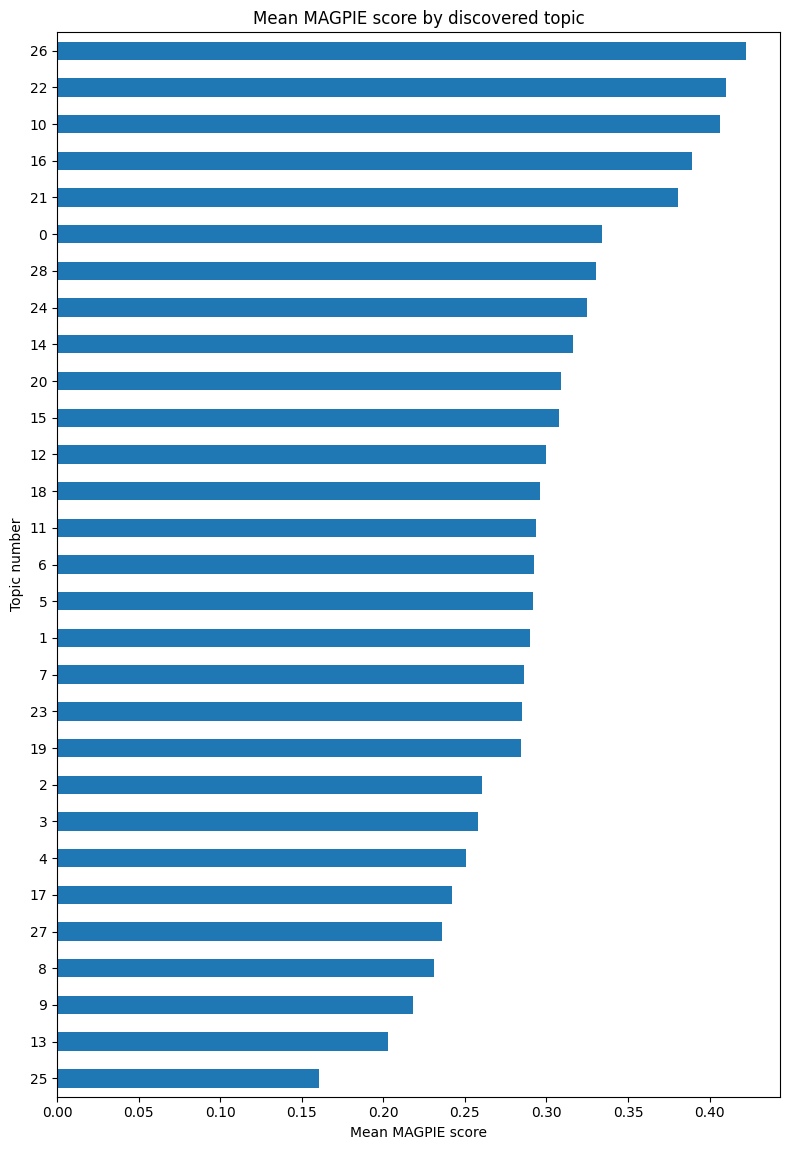

In [ ]:
import matplotlib.pyplot as plt

# Plot the mean MAGPIE score for each discovered topic.
topic_means_plot = (
    df_clustered.groupby("topic")["bias_score"]
    .mean()
    .sort_values()
)

topic_means_plot.plot(
    kind="barh",
    figsize=(8, max(4, len(topic_means_plot) * 0.4))
)

plt.xlabel("Mean MAGPIE score")
plt.ylabel("Topic number")
plt.title("Mean MAGPIE score by discovered topic")
plt.tight_layout()
plt.show()

## Final results

The topic analysis identified 29 content topics among the 5,000 sampled German news articles, with 2,010 articles classified as BERTopic outliers and excluded from topic-level comparisons.

MAGPIE scores differed significantly across the 29 topic groups (Kruskal-Wallis H = 339.672, p < 0.001). Pairwise Mann-Whitney U tests with Bonferroni correction identified 123 significant differences among the 406 possible topic pairs.

In the regression analysis, adding topic membership to political stance and article length increased R-squared from 0.0168 to 0.1258, corresponding to an additional 0.1090 in explained variance. Topic membership was jointly significant in the full model using HC3-robust standard errors (F(28, 2960) = 13.499, p < 0.001).

Political stance retained a small positive association with MAGPIE scores after controlling for topic and article length (β = 0.0116, HC3 p = 0.0268). Therefore, the topic analysis indicates that MAGPIE scores show substantial variation across content topics, while topic variation does not completely account for the observed association between political stance and MAGPIE scores.

These results are interpreted as exploratory evidence about factors associated with MAGPIE scores in the sampled German news articles. They do not establish that topic causes MAGPIE scores or that MAGPIE measures topic-specific subjectivity exclusively.